In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd


DATA_PATH = Path("data/processed/movies_cleaned.csv")
EMBEDDINGS_DIR = Path("artifacts/embeddings")

EMBEDDING_PATHS = {
    "minilm": EMBEDDINGS_DIR / "minilm_embeddings.npy",
    "mpnet": EMBEDDINGS_DIR / "mpnet_embeddings.npy",
    "gte_modernbert": EMBEDDINGS_DIR / "gte_modernbert_embeddings.npy",
}


# Load dataset
movies_df = pd.read_csv(DATA_PATH)

# Load embedding matrices
embeddings = {
    model_name: np.load(file_path)
    for model_name, file_path in EMBEDDING_PATHS.items()
}

print(f"Number of movies: {len(movies_df):,}")
print(f"Dataset shape: {movies_df.shape}")
print()


validation_rows = []

for model_name, matrix in embeddings.items():
    if matrix.ndim != 2:
        raise ValueError(
            f"{model_name}: expected a 2D matrix, got shape {matrix.shape}"
        )

    row_count_matches = matrix.shape[0] == len(movies_df)
    nan_count = int(np.isnan(matrix).sum())
    inf_count = int(np.isinf(matrix).sum())

    l2_norms = np.linalg.norm(matrix, axis=1)

    validation_rows.append(
        {
            "model": model_name,
            "shape": str(matrix.shape),
            "num_movies": matrix.shape[0],
            "embedding_dimension": matrix.shape[1],
            "dtype": str(matrix.dtype),
            "row_count_matches": row_count_matches,
            "nan_count": nan_count,
            "inf_count": inf_count,
            "mean_l2_norm": l2_norms.mean(),
            "std_l2_norm": l2_norms.std(),
            "min_l2_norm": l2_norms.min(),
            "max_l2_norm": l2_norms.max(),
        }
    )

    if not row_count_matches:
        raise ValueError(
            f"{model_name}: {matrix.shape[0]} embeddings, "
            f"but dataset contains {len(movies_df)} movies."
        )

    if nan_count > 0:
        raise ValueError(f"{model_name}: found {nan_count} NaN values.")

    if inf_count > 0:
        raise ValueError(f"{model_name}: found {inf_count} infinite values.")


embedding_validation_df = pd.DataFrame(validation_rows)

embedding_validation_df

Number of movies: 9,967
Dataset shape: (9967, 12)



,model,shape,num_movies,embedding_dimension,dtype,row_count_matches,nan_count,inf_count,mean_l2_norm,std_l2_norm,min_l2_norm,max_l2_norm
0,minilm,"(9967, 384)",9967,384,float32,True,0,0,1.0,4.135931e-08,1.000000,1.0
1,mpnet,"(9967, 768)",9967,768,float32,True,0,0,1.0,4.590942e-08,1.000000,1.0
2,gte_modernbert,"(9967, 768)",9967,768,float16,True,0,0,1.0,2.441406e-04,0.999512,1.0


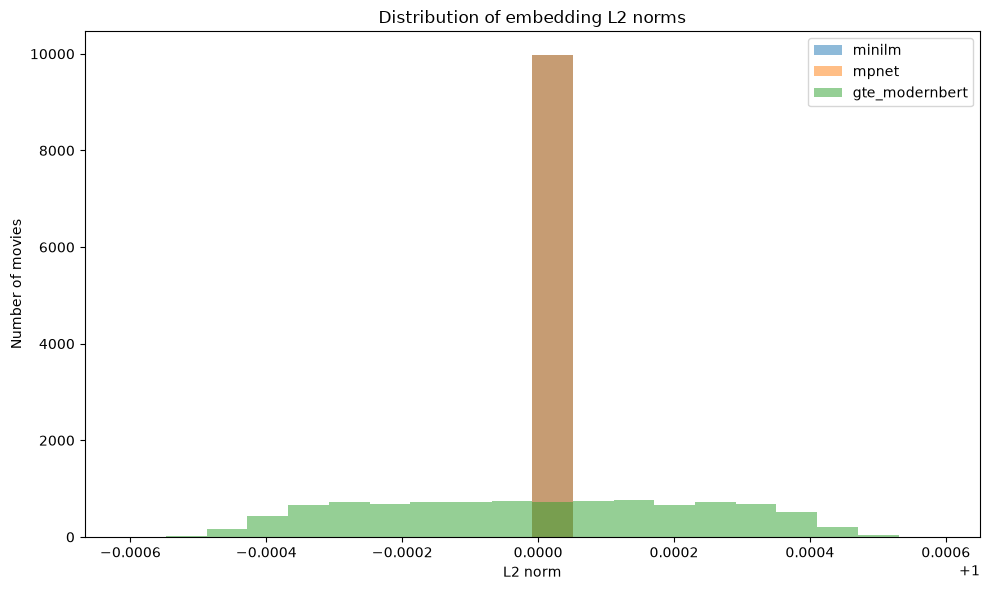

In [4]:
plt.figure(figsize=(10, 6))

all_l2_norms = np.concatenate(list(l2_norms_by_model.values()))

norm_min = float(all_l2_norms.min())
norm_max = float(all_l2_norms.max())

# Proširi opseg ako su norme numerički skoro identične
if np.isclose(norm_min, norm_max):
    margin = max(abs(norm_min) * 1e-6, 1e-8)
else:
    margin = (norm_max - norm_min) * 0.05

hist_range = (
    norm_min - margin,
    norm_max + margin,
)

for model_name, l2_norms in l2_norms_by_model.items():
    plt.hist(
        l2_norms,
        bins=20,
        range=hist_range,
        alpha=0.5,
        label=model_name,
    )

plt.xlabel("L2 norm")
plt.ylabel("Number of movies")
plt.title("Distribution of embedding L2 norms")
plt.legend()
plt.tight_layout()
plt.show()

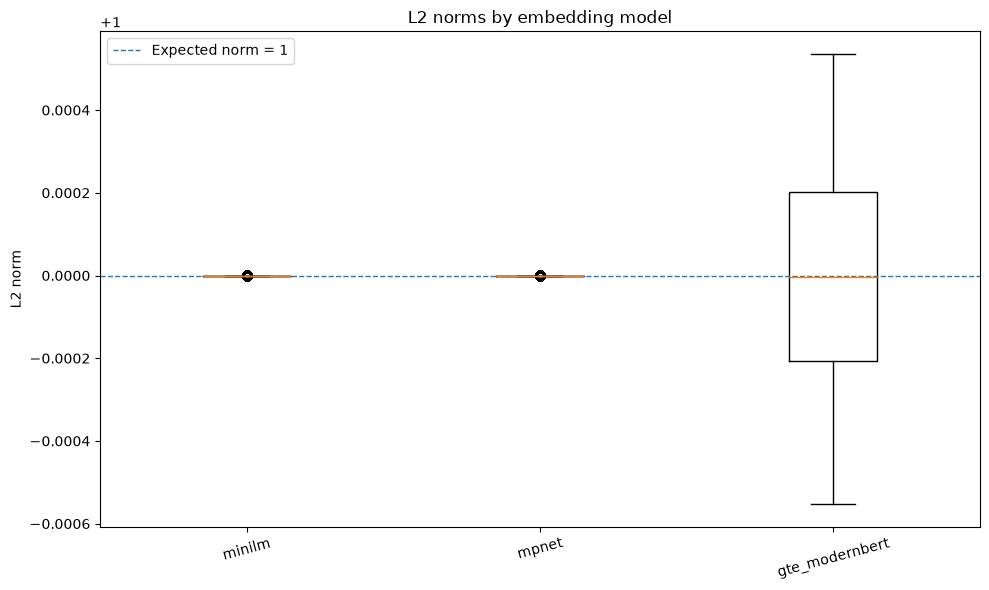

In [5]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    list(l2_norms_by_model.values()),
    tick_labels=list(l2_norms_by_model.keys()),
)

plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1,
    label="Expected norm = 1",
)

plt.ylabel("L2 norm")
plt.title("L2 norms by embedding model")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
for model_name, l2_norms in l2_norms_by_model.items():
    print(
        model_name,
        np.unique(np.round(l2_norms, decimals=6))[:10]
    )

minilm [1.]
mpnet [1.]
gte_modernbert [0.999447 0.999453 0.999471 0.999473 0.999481 0.999483 0.999486 0.999487
 0.999499 0.999501]


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
def calculate_cosine_scores(
    query_index: int,
    embedding_matrix: np.ndarray,
) -> np.ndarray:
    query_embedding = embedding_matrix[query_index].reshape(1, -1)

    return cosine_similarity(
        query_embedding,
        embedding_matrix,
    ).ravel()

In [13]:
TITLE_COLUMN = "title"


def get_similar_movies(
    title: str,
    movies_df: pd.DataFrame,
    embedding_matrix: np.ndarray,
    top_k: int = 10,
) -> pd.DataFrame:
    title_matches = movies_df[
        movies_df[TITLE_COLUMN].str.casefold() == title.casefold()
    ]

    if title_matches.empty:
        raise ValueError(f"Film '{title}' nije pronađen.")

    if len(title_matches) > 1:
        print(
            f"Pronađeno je {len(title_matches)} filmova sa naslovom "
            f"'{title}'. Koristi se prvi."
        )

    query_index = title_matches.index[0]

    cosine_scores = calculate_cosine_scores(
        query_index=query_index,
        embedding_matrix=embedding_matrix,
    )

    # Ukloni sam film iz rezultata
    cosine_scores[query_index] = -np.inf

    top_indices = np.argsort(cosine_scores)[::-1][:top_k]

    results = movies_df.loc[
        top_indices,
        [TITLE_COLUMN, "overview"],
    ].copy()

    results.insert(
        0,
        "rank",
        range(1, len(results) + 1),
    )

    results["cosine_similarity"] = cosine_scores[top_indices]

    return results.reset_index(drop=True)

In [15]:
selected_titles = [
    "The Dark Knight",
    "Inception",
    "Toy Story",
]

similarity_results = {}

for title in selected_titles:
    similarity_results[title] = {}

    for model_name, embedding_matrix in embeddings.items():
        similarity_results[title][model_name] = get_similar_movies(
            title=title,
            movies_df=movies_df,
            embedding_matrix=embedding_matrix,
            top_k=10,
        )

        print(f"\n{'=' * 80}")
        print(f"Query: {title}")
        print(f"Model: {model_name}")
        print(f"{'=' * 80}")

        display(
            similarity_results[title][model_name][
                ["rank", TITLE_COLUMN, "cosine_similarity"]
            ]
        )


Query: The Dark Knight
Model: minilm


,rank,title,cosine_similarity
0,1,"Batman: The Long Halloween, Part One",0.764030
1,2,"Batman: The Long Halloween, Part Two",0.725439
2,3,Batman,0.707406
3,4,The Dark Knight Rises,0.701888
4,5,Batman: The Killing Joke,0.648050
5,6,Batman: Gotham by Gaslight,0.647677
6,7,Batman v Superman: Dawn of Justice,0.641332
7,8,The Batman,0.633064
8,9,Batman: Mystery of the Batwoman,0.622899
9,10,Batman Begins,0.614793



Query: The Dark Knight
Model: mpnet


,rank,title,cosine_similarity
0,1,The Dark Knight Rises,0.828235
1,2,"Batman: The Long Halloween, Part One",0.792702
2,3,The Batman,0.772711
3,4,Batman Begins,0.770356
4,5,Batman,0.764322
5,6,"Batman: The Long Halloween, Part Two",0.760239
6,7,Batman: Gotham by Gaslight,0.712486
7,8,Batman: The Killing Joke,0.705330
8,9,Batman v Superman: Dawn of Justice,0.695864
9,10,Batman: Year One,0.689751



Query: The Dark Knight
Model: gte_modernbert


...

,rank,title,cosine_similarity
0,1,Toy Story 3,0.758612
1,2,Toy Story 2,0.740060
2,3,Toy Story 4,0.544401
3,4,Buzz Lightyear of Star Command: The Adventure ...,0.476463
4,5,Lightyear,0.428794
5,6,Child's Play,0.422682
6,7,Child's Play 2,0.394639
7,8,Luxo Jr.,0.391736
8,9,A Very Harold & Kumar Christmas,0.390390
9,10,Deck the Halls,0.388122



Query: Toy Story
Model: mpnet


,rank,title,cosine_similarity
0,1,Toy Story 3,0.832999
1,2,Toy Story 2,0.816954
2,3,Toy Story 4,0.645552
3,4,Buzz Lightyear of Star Command: The Adventure ...,0.512554
4,5,Child's Play 2,0.506892
5,6,Christopher Robin,0.498898
6,7,Elf,0.491206
7,8,Lightyear,0.484561
8,9,Mickey's Once Upon a Christmas,0.475209
9,10,Hawaiian Vacation,0.470373



Query: Toy Story
Model: gte_modernbert


,rank,title,cosine_similarity
0,1,Toy Story 2,0.797594
1,2,Toy Story 3,0.797272
2,3,Toy Story 4,0.757378
3,4,Lightyear,0.687740
4,5,Buzz Lightyear of Star Command: The Adventure ...,0.683065
5,6,Toy Story That Time Forgot,0.676319
6,7,Elf,0.672720
7,8,The Little Vampire,0.670199
8,9,Free Willy,0.661251
9,10,Woody Woodpecker,0.658766


In [16]:
from itertools import combinations


def calculate_top_k_overlap(
    first_results: pd.DataFrame,
    second_results: pd.DataFrame,
    title_column: str,
) -> dict[str, float | int]:
    first_titles = set(first_results[title_column])
    second_titles = set(second_results[title_column])

    intersection_size = len(first_titles & second_titles)
    union_size = len(first_titles | second_titles)

    jaccard_score = (
        intersection_size / union_size
        if union_size > 0
        else 0.0
    )

    overlap_percentage = (
        intersection_size / len(first_titles) * 100
        if first_titles
        else 0.0
    )

    return {
        "shared_movies": intersection_size,
        "jaccard_score": jaccard_score,
        "overlap_percentage": overlap_percentage,
    }

In [18]:
summary_overlap_df = (
    top_10_overlap_df
    .groupby(["model_1", "model_2"], as_index=False)
    .agg(
        mean_shared_movies=("shared_movies", "mean"),
        mean_jaccard_score=("jaccard_score", "mean"),
        mean_overlap_percentage=("overlap_percentage", "mean"),
    )
)

summary_overlap_df

,model_1,model_2,mean_shared_movies,mean_jaccard_score,mean_overlap_percentage
0,minilm,gte_modernbert,4.666667,0.327635,46.666667
1,minilm,mpnet,5.666667,0.452621,56.666667
2,mpnet,gte_modernbert,5.000000,0.359381,50.000000


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


RANDOM_STATE = 42
K_VALUES = range(2, 13)
SILHOUETTE_SAMPLE_SIZE = min(2_000, len(movies_df))

kmeans_evaluation_rows = []

for model_name, embedding_matrix in embeddings.items():
    print(f"\nModel: {model_name}")

    for k in K_VALUES:
        kmeans = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=RANDOM_STATE,
        )

        cluster_labels = kmeans.fit_predict(embedding_matrix)

        silhouette = silhouette_score(
            embedding_matrix,
            cluster_labels,
            metric="cosine",
            sample_size=SILHOUETTE_SAMPLE_SIZE,
            random_state=RANDOM_STATE,
        )

        kmeans_evaluation_rows.append(
            {
                "model": model_name,
                "k": k,
                "inertia": kmeans.inertia_,
                "silhouette_score": silhouette,
            }
        )

        print(
            f"k={k:2d} | "
            f"inertia={kmeans.inertia_:,.2f} | "
            f"silhouette={silhouette:.4f}"
        )


kmeans_evaluation_df = pd.DataFrame(kmeans_evaluation_rows)
kmeans_evaluation_df


Model: minilm
k= 2 | inertia=8,209.74 | silhouette=0.0506
k= 3 | inertia=8,091.58 | silhouette=0.0419
k= 4 | inertia=8,003.60 | silhouette=0.0399
k= 5 | inertia=7,933.85 | silhouette=0.0322
k= 6 | inertia=7,874.77 | silhouette=0.0331
k= 7 | inertia=7,822.31 | silhouette=0.0342
k= 8 | inertia=7,781.81 | silhouette=0.0324
k= 9 | inertia=7,742.87 | silhouette=0.0335
k=10 | inertia=7,708.24 | silhouette=0.0337
k=11 | inertia=7,674.75 | silhouette=0.0336
k=12 | inertia=7,644.64 | silhouette=0.0298

Model: mpnet
k= 2 | inertia=7,414.70 | silhouette=0.0559
k= 3 | inertia=7,269.84 | silhouette=0.0385
k= 4 | inertia=7,173.99 | silhouette=0.0311
k= 5 | inertia=7,100.99 | silhouette=0.0351
k= 6 | inertia=7,040.22 | silhouette=0.0370
k= 7 | inertia=6,990.03 | silhouette=0.0384
k= 8 | inertia=6,941.21 | silhouette=0.0334
k= 9 | inertia=6,896.50 | silhouette=0.0330
k=10 | inertia=6,859.85 | silhouette=0.0293
k=11 | inertia=6,824.68 | silhouette=0.0313
k=12 | inertia=6,792.08 | silhouette=0.0316

Mo

,model,k,inertia,silhouette_score
0,minilm,2,8209.740234,0.050629
1,minilm,3,8091.581543,0.041937
2,minilm,4,8003.604004,0.039854
3,minilm,5,7933.849121,0.032212
4,minilm,6,7874.772949,0.033140
5,minilm,7,7822.307617,0.034186
6,minilm,8,7781.814453,0.032422
7,minilm,9,7742.869141,0.033454
8,minilm,10,7708.242676,0.033722
9,minilm,11,7674.752930,0.033565


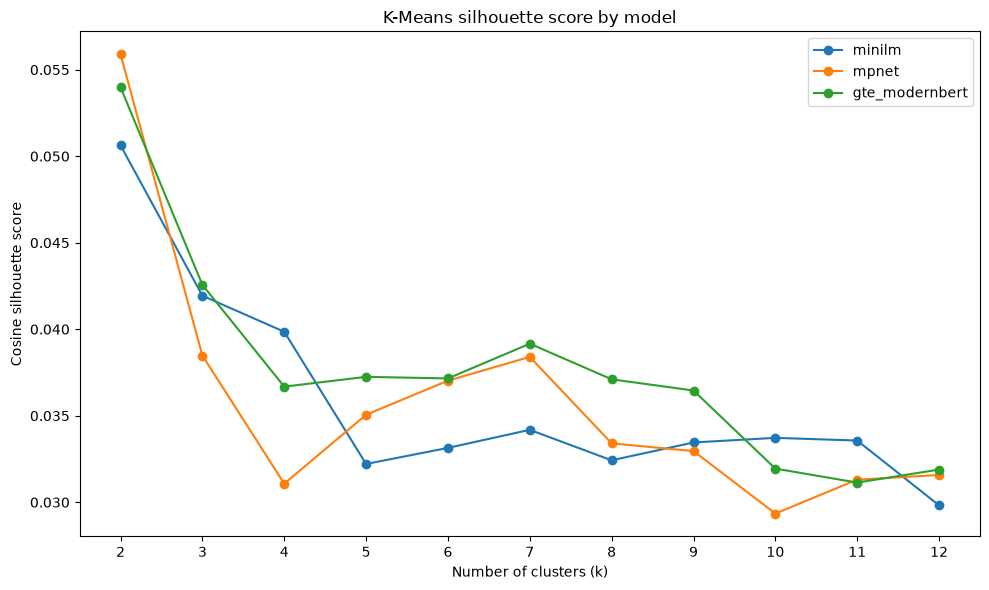

In [20]:
plt.figure(figsize=(10, 6))

for model_name in embeddings:
    model_results = kmeans_evaluation_df[
        kmeans_evaluation_df["model"] == model_name
    ]

    plt.plot(
        model_results["k"],
        model_results["silhouette_score"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Number of clusters (k)")
plt.ylabel("Cosine silhouette score")
plt.title("K-Means silhouette score by model")
plt.xticks(list(K_VALUES))
plt.legend()
plt.tight_layout()
plt.show()